In [1]:
using Pkg
ENV["JULIA_REVISE_POLL"]="1"
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")

In [2]:
using Revise

In [3]:
using PyPlot, PyCall, Peaks, JJDFTX, LinearAlgebra

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [5]:
write_map_write_h("wannier-0.289", [12, 12, 1], spin=Val('u'))

In [6]:
Hwannierup, cellmapup = hwannier("wannier-0.289Up.txt", "wannier-0.289Up.map.txt"), np.loadtxt("wannier-0.289Up.map.txt");
Hwannierdn, cellmapdn = hwannier("wannier-0.289Dn.txt", "wannier-0.289Dn.map.txt"), np.loadtxt("wannier-0.289Dn.map.txt");

In [9]:
bands = np.reshape(np.fromfile("Na-bands-0.289.eigenvals"), (112, -1))*27.2
bandsup = bands[1:56, :]
bandsdn = bands[57:end, :];

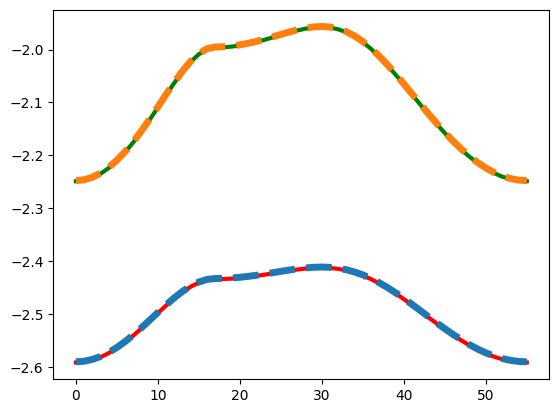

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fa4624968b0>

In [32]:
plotwannierbands(Hwannierup, cellmapup, 1, linewidth=3, color="red")
plotwannierbands(Hwannierdn, cellmapdn, 1, linewidth=3, color="green")
plot(bandsup[:, 109], linestyle="dashed", linewidth=5)
plot(bandsdn[:, 109], linestyle="dashed", linewidth=5)

In [40]:
maximum(bandsup[:, 109]) - minimum(bandsup[:, 109])

0.17922458254975826

In [19]:
kpts = bandstructkpoints2q();
lattice_vectors = loadlattice("../Sodium-74.out")[2]

Lattice loaded from output file in lattice format and in nested array format: 
Note that the lattice format is by convention in Bohrs to be compatible with JDFTX whereas the nested
    array format is in angstroms


3-element Vector{Vector{Float64}}:
 [8.7558684774, -2.1665141392400002, 0.0]
 [-6.2541842099, -6.499563584800001, 0.0]
 [0.0, 0.0, 21.16708]

In [31]:
area = abs(cross(lattice_vectors[1], lattice_vectors[2])[3])
target_area = 4.727486978767153*4.727486978767153*0.529*0.529*sqrt(3)/2*13
println((target_area-area)/target_area*100)

-0.06704974230504908


In [23]:
pwd()

"/home/gridsan/aligho/Plasmons/Plasmons_Paper/Moire_Figs/Moire13_with_Alkali/Sodium/plasmons"

In [33]:
impols = []
for q in kpts
    up = im_polarization(Hwannierup, cellmapup, lattice_vectors, q, -2.5;spin=1, mesh=30, histogram_width=30, normalized=true, verbose=true) 
    push!(impols, up)
end

[0.0, 0.0, 0.0]
[0.029411764706, 0.0, 0.0]
[0.058823529412, 0.0, 0.0]
[0.088235294118, 0.0, 0.0]
[0.117647058824, 0.0, 0.0]
[0.147058823529, 0.0, 0.0]
[0.176470588235, 0.0, 0.0]
[0.205882352941, 0.0, 0.0]
[0.235294117647, 0.0, 0.0]
[0.264705882353, 0.0, 0.0]
[0.294117647059, 0.0, 0.0]
[0.323529411765, 0.0, 0.0]
[0.352941176471, 0.0, 0.0]
[0.382352941176, 0.0, 0.0]
[0.411764705882, 0.0, 0.0]
[0.441176470588, 0.0, 0.0]
[0.470588235294, 0.0, 0.0]
[0.5, 0.0, 0.0]
[0.512820512769, -0.025641025385, 0.0]
[0.525641025538, -0.051282050769, 0.0]
[0.538461538308, -0.076923076154, 0.0]
[0.551282051077, -0.102564101538, 0.0]
[0.564102563846, -0.128205126923, 0.0]
[0.576923076615, -0.153846152308, 0.0]
[0.589743589385, -0.179487177692, 0.0]
[0.602564102154, -0.205128203077, 0.0]
[0.615384614923, -0.230769228462, 0.0]
[0.628205127692, -0.256410253846, 0.0]
[0.641025640462, -0.282051279231, 0.0]
[0.653846153231, -0.307692304615, 0.0]
[0.666666666, -0.33333333, 0.0]
[0.63999999936, -0.3199999968, 0.0]


In [38]:
realpols = zeros(56, 100)

for (i, line) in enumerate(readlines("bandstruct.kpoints")[3:end])
    q = parse.(Float64, split(line)[2:4])
    b1 = unnormalize_kvector(lattice_vectors, q)
    screening=exp(-6*sqrt(sum(b1.^2)))
    for (j, omega) in enumerate(range(0.3, 0.45, length=100))
        eps = return_2d_epsilon(q, lattice_vectors, omega, impols[i], 100, 30)
        realpols[i, j] = real(eps)+2*6*screening/(1+6*(1-screening))
    end
end

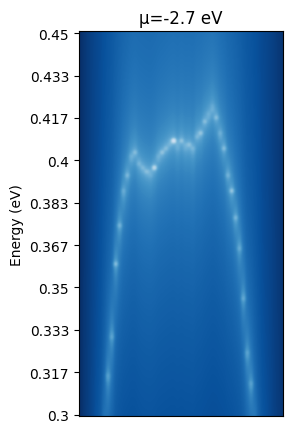

PyObject Text(0.5, 1.0, 'μ=-2.7 eV')

In [39]:
energyrange = round.(range(0.3, 0.45 , length=10), digits=3)
energyrange2 = round.(range(0.3, 0.45, length=100), digits=3)

figure(figsize=(10, 5))
subplot(1, 3, 1)
imshow(transpose(log.(abs.(realpols[2:end-2, :])) .+0.1), interpolation="gaussian", cmap="Blues", origin="lower")
ylabel("Energy (eV)")
yticks(range(0, 99, length=10), energyrange )
xticks([])
title("μ=-2.7 eV")
#hlines(round(argmin(abs.(energyrange2 .- 1.07))), 0, 52, color="black", linestyle="dotted", linewidth=4)


In [42]:
0.18+0.19

0.37

In [1]:
pwd()

"/home/gridsan/aligho/Plasmons/Plasmons_Paper/Moire_Figs/Moire13_with_Alkali/Sodium/plasmons"